In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Configuration des graphiques
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Configuration d'affichage pour pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [4]:
product_columns = [
    "code",
    "product_name",
    "quantity",
    "categories_tags",
    "nutriscore_grade",
    "brands",
    "image_url",
    "main_category",
    "packaging_tags",
    "labels_tags",
    "origins_tags"
]

nutriment_columns = [
    "energy_100g",
    "fat_100g",
    "saturated-fat_100g",
    "sugars_100g",
    "fiber_100g",
    "proteins_100g",
    "salt_100g",
    "fruits-vegetables-legumes_100g"
]

columns = product_columns + nutriment_columns

In [5]:
dtypes = {"code": "str"}

In [6]:
chunks = pd.read_csv(
    "../data/en.openfoodfacts.org.products.csv",
    sep="\t",
    usecols=columns,
    iterator=True,
    chunksize=1000,
    on_bad_lines="warn",
    dtype=dtypes,
    # nrows=10000
)

# results = []
# for chunk in chunks:
#     chunk_filter = chunk[chunk["code"].str.startswith("200", na=False)]
#     results.append(chunk_filter)

df = pd.concat(chunks, ignore_index=True)

In [7]:
# Conversion des colonnes de nutriments
for col in nutriment_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [8]:
# Vérification des infos
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 4532767 entries, 0 to 4532766
Data columns (total 19 columns):
 #   Column                          Dtype  
---  ------                          -----  
 0   code                            str    
 1   product_name                    str    
 2   quantity                        str    
 3   packaging_tags                  object 
 4   brands                          object 
 5   categories_tags                 str    
 6   origins_tags                    object 
 7   labels_tags                     object 
 8   nutriscore_grade                str    
 9   main_category                   str    
 10  image_url                       object 
 11  energy_100g                     float64
 12  fat_100g                        float64
 13  saturated-fat_100g              float64
 14  sugars_100g                     float64
 15  fiber_100g                      float64
 16  proteins_100g                   float64
 17  salt_100g                       float6

,energy_100g,fat_100g,saturated-fat_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,fruits-vegetables-legumes_100g
count,2.235954e+06,2.211249e+06,2.128089e+06,2.144239e+06,1.032253e+06,2.214926e+06,1.951790e+06,726769.000000
mean,7.368853e+03,2.179122e+01,5.469788e+00,5.478482e+26,5.920308e+06,1.756287e+03,1.146616e+02,14.298841
std,6.993943e+06,1.180501e+04,4.048320e+02,8.022261e+29,6.015011e+09,1.830289e+06,1.571302e+05,35.848559
min,-2.333333e+03,-1.433973e+00,-3.992188e+00,-8.730000e-02,-3.333333e+00,-4.761905e+00,-4.543632e-01,-65.887256
25%,4.618000e+02,1.170000e+00,2.000000e-01,6.000000e-01,1.379642e-01,2.000000e+00,9.750000e-02,0.000000
50%,1.060300e+03,7.300000e+00,1.914894e+00,3.200000e+00,1.666667e+00,6.700000e+00,5.708661e-01,0.000000
75%,1.653800e+03,2.100000e+01,7.000000e+00,1.433333e+01,3.900000e+00,1.400000e+01,1.400000e+00,10.550000
max,1.000000e+10,1.755400e+07,5.880000e+05,1.174717e+33,6.111242e+12,2.522222e+09,2.195208e+08,13461.000000


# Analyse des données

In [9]:
print("===   energy_100g   ===")
print("Nombre de valeurs NaN :\t\t", df["energy_100g"].isna().sum())
print("Nombre de valeurs nulles :\t", (df["energy_100g"] == 0).sum())

for col in nutriment_columns[1:]:
    print()
    print(f"{'='*3} {col:^15s} {'='*3}")
    print("Nombre de valeurs NaN :\t\t", df[col].isna().sum())
    print("Nombre de valeurs (> 100g) :\t", (df[col] > 100).sum())

===   energy_100g   ===
Nombre de valeurs NaN :		 2296813
Nombre de valeurs nulles :	 35621

===    fat_100g     ===
Nombre de valeurs NaN :		 2321518
Nombre de valeurs (> 100g) :	 404

=== saturated-fat_100g ===
Nombre de valeurs NaN :		 2404678
Nombre de valeurs (> 100g) :	 162

===   sugars_100g   ===
Nombre de valeurs NaN :		 2388528
Nombre de valeurs (> 100g) :	 307

===   fiber_100g    ===
Nombre de valeurs NaN :		 3500514
Nombre de valeurs (> 100g) :	 115

===  proteins_100g  ===
Nombre de valeurs NaN :		 2317841
Nombre de valeurs (> 100g) :	 287

===    salt_100g    ===
Nombre de valeurs NaN :		 2580977
Nombre de valeurs (> 100g) :	 1038

=== fruits-vegetables-legumes_100g ===
Nombre de valeurs NaN :		 3805998
Nombre de valeurs (> 100g) :	 1457


In [10]:
# Nombre de lignes dupliquées
print("Nombre de lignes dupliquées:\t", df.duplicated().sum())

Nombre de lignes dupliquées:	 0


In [11]:
# Nombre de valeurs uniques
for col in df:
    print(f"{col:<20s} :\t{df[col].nunique()}")

code                 :	4532707
product_name         :	2633458
quantity             :	74186
packaging_tags       :	49157
brands               :	482966
categories_tags      :	197832
origins_tags         :	19546
labels_tags          :	133510
nutriscore_grade     :	9
main_category        :	80179
image_url            :	3349707
energy_100g          :	255665
fat_100g             :	39112
saturated-fat_100g   :	32397
sugars_100g          :	38914
fiber_100g           :	52771
proteins_100g        :	37272
salt_100g            :	60093
fruits-vegetables-legumes_100g :	88921


In [12]:
# Nombre de valeurs dupliquées par colonne
for col in df:
    print(f"{col:<20s} :\t{df[col].duplicated().sum()}")

code                 :	60
product_name         :	1899308
quantity             :	4458580
packaging_tags       :	4483609
brands               :	4049800
categories_tags      :	4334934
origins_tags         :	4513220
labels_tags          :	4399256
nutriscore_grade     :	4532757
main_category        :	4452587
image_url            :	1183059
energy_100g          :	4277101
fat_100g             :	4493654
saturated-fat_100g   :	4500369
sugars_100g          :	4493852
fiber_100g           :	4479995
proteins_100g        :	4495494
salt_100g            :	4472673
fruits-vegetables-legumes_100g :	4443845


# Distribution des valeurs

c:\Users\Administrateur\Documents\Cours\NutriScope - Projet\Nutriscope_team_delegue\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\Administrateur\Documents\Cours\NutriScope - Projet\Nutriscope_team_delegue\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


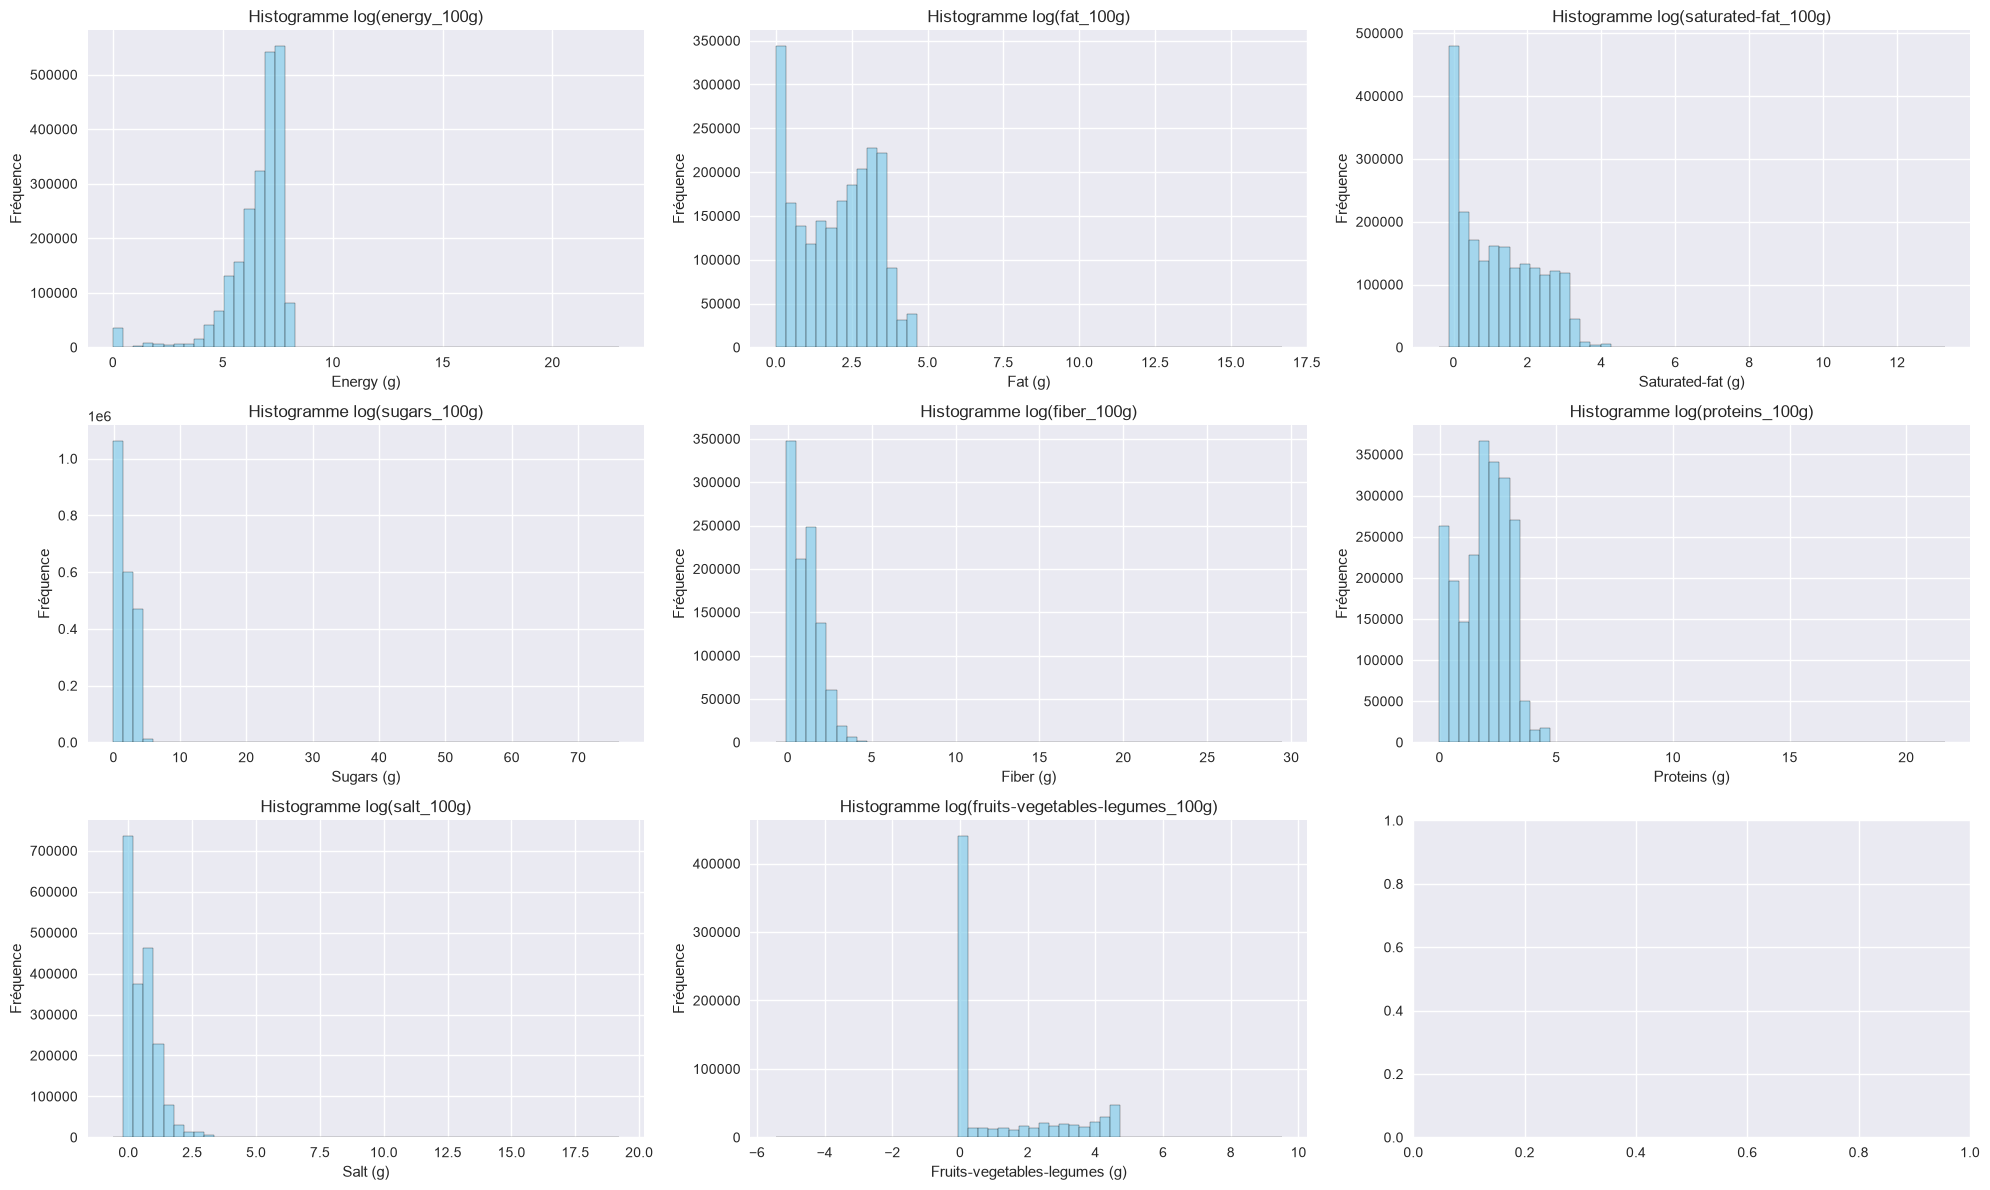

In [13]:
from matplotlib.cbook import flatten

# Distribution des valeurs nutritionnelles
nutriment_col_count = len(nutriment_columns)
fig, axes = plt.subplots(int(np.ceil(nutriment_col_count / 3)), 3, figsize=(20, 12))
for ax, col in zip(flatten(axes), nutriment_columns):
    data = np.log1p(df[col][df[col].notna()])
    data = data[data > -np.inf] # Remove log = -inf values
    ax.hist(data, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    ax.set_title(f'Histogramme log({col})')
    ax.set_xlabel(f'{col.split("_")[0].capitalize()} (g)')
    ax.set_ylabel('Fréquence')

plt.tight_layout()
plt.savefig("../data/distribution_nutrition.png")

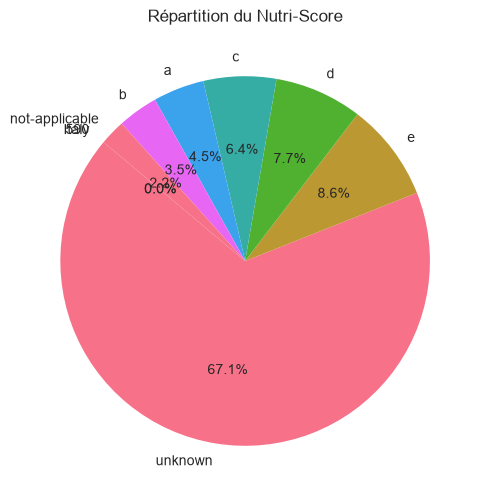

In [14]:
# Distribution du nutriscore
nutriscore_counts = df['nutriscore_grade'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(nutriscore_counts, labels=nutriscore_counts.index, autopct='%1.1f%%', startangle=140)
plt.title("Répartition du Nutri-Score")

plt.savefig("../data/distribution_nutriscore.png")

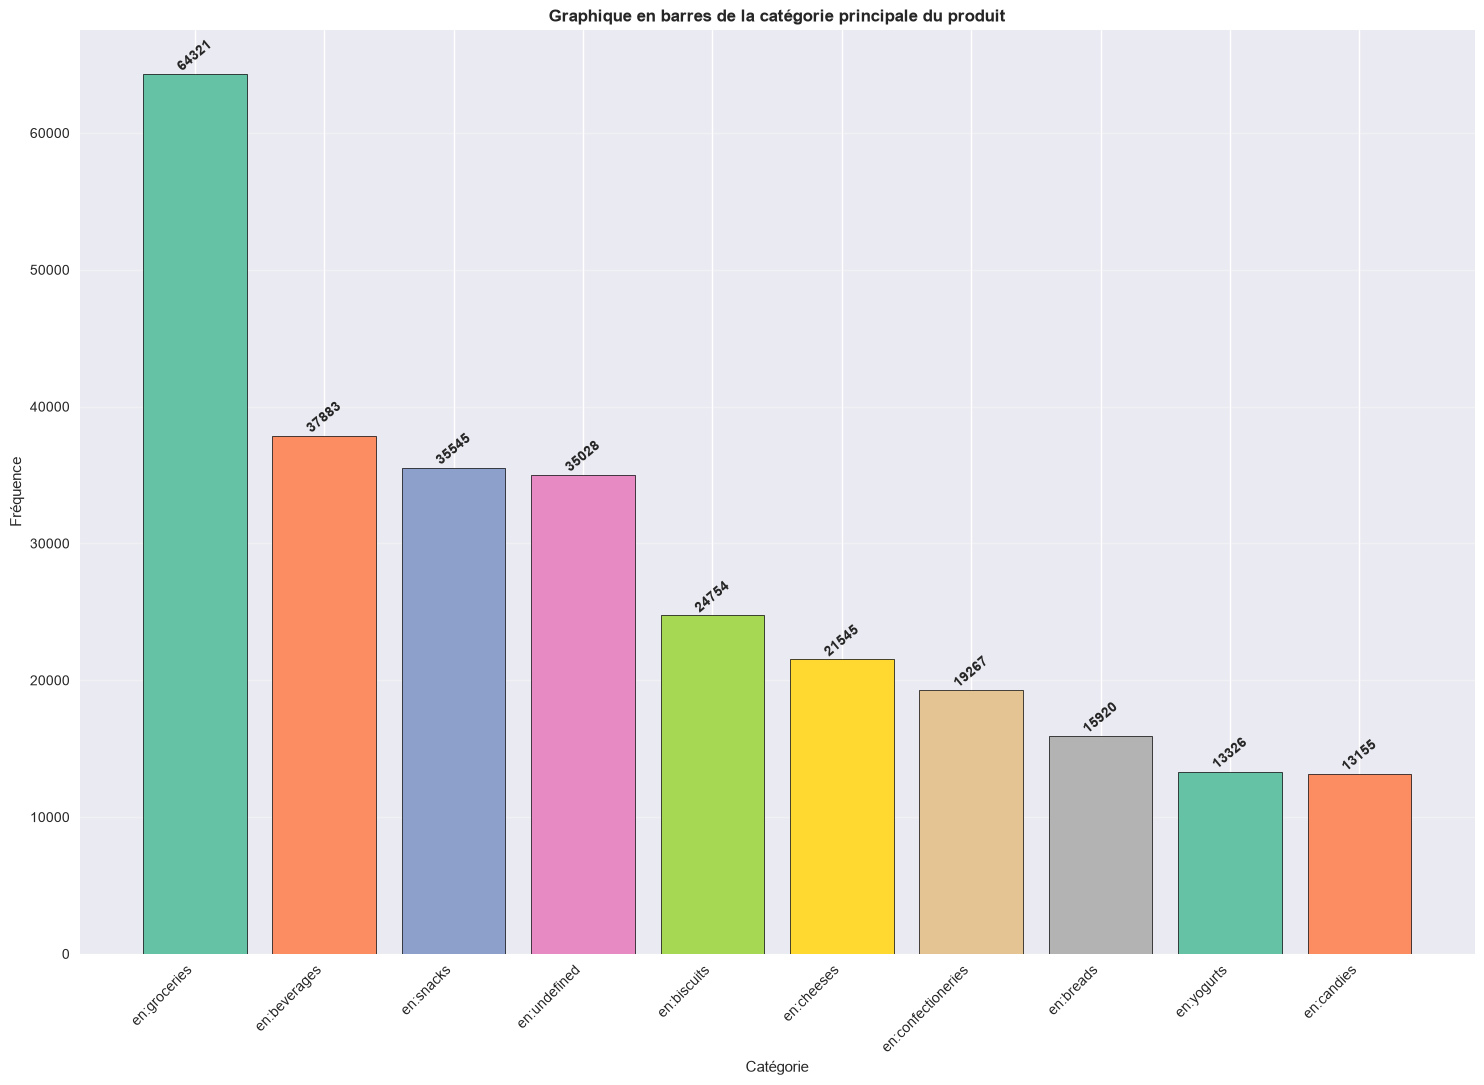

In [ ]:
main_categories_count = df["main_category"].value_counts().sort_values(ascending=False).head(10)

_, ax = plt.subplots(1, 1, figsize=(18, 12))
bars = ax.bar(
    range(len(main_categories_count)),
    main_categories_count.values, 
    color=sns.color_palette("Set2", len(main_categories_count)), 
    edgecolor='black', linewidth=0.5
)

# Personnalisation
ax.set_title("Graphique en barres de la catégorie principale du produit", fontweight='bold')
ax.set_xlabel("Catégorie")
ax.set_ylabel("Fréquence")
ax.set_xticks(range(len(main_categories_count)))
ax.set_xticklabels(main_categories_count.index, rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')

# Ajout des valeurs sur les barres
for j, bar in enumerate(bars):
    height = bar.get_height()
    tx = ax.text(bar.get_x() + bar.get_width()/2., height + 0.1,
            f'{int(height)}', rotation=40, ha='center', va='bottom', fontweight='bold')


plt.savefig("../data/distribution_main_category.png")

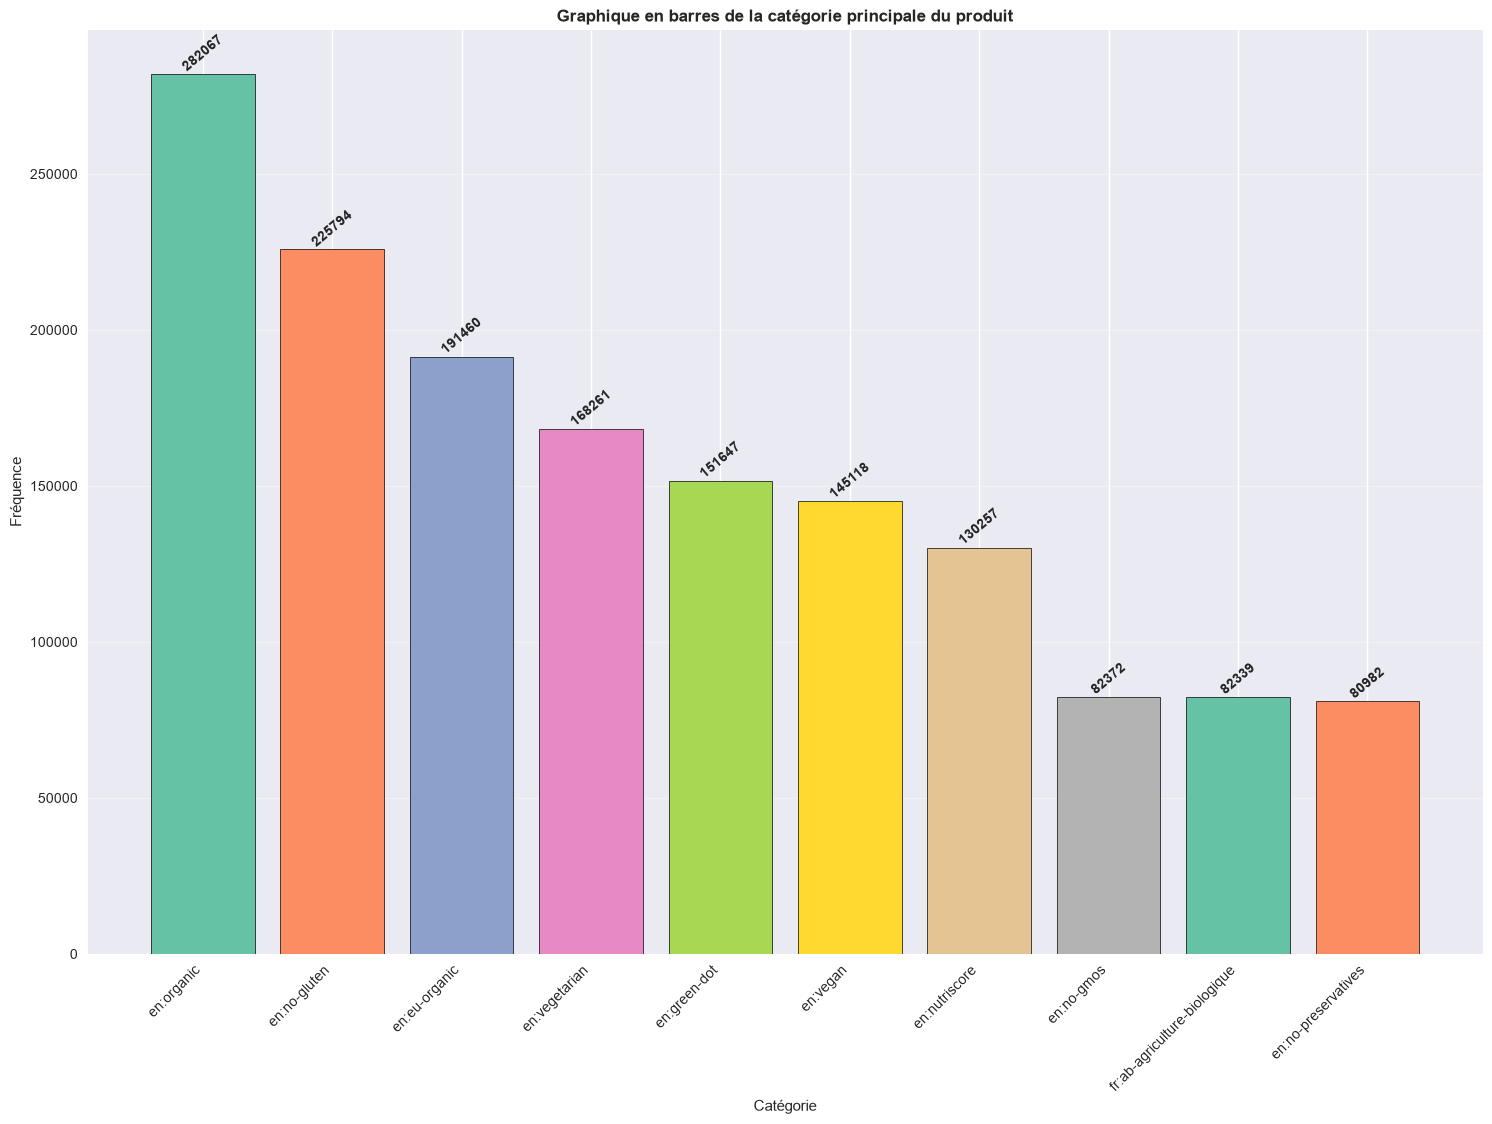

In [ ]:
from collections import Counter

def tags_count(series):
    result = Counter()
    for value in series:
        if not isinstance(value, str):
            continue
        for tag in value.split(","):
            tag = tag.strip()
            result[tag] += 1

    return pd.Series(result)

labels_tags_count = tags_count(df["labels_tags"]).sort_values(ascending=False).head(10)

_, ax = plt.subplots(1, 1, figsize=(18, 12))
bars = ax.bar(
    range(len(labels_tags_count)),
    labels_tags_count.values, 
    color=sns.color_palette("Set2", len(labels_tags_count)), 
    edgecolor='black', linewidth=0.5
)

# Personnalisation
ax.set_title("Graphique en barres de la catégorie principale du produit", fontweight='bold')
ax.set_xlabel("Catégorie")
ax.set_ylabel("Fréquence")
ax.set_xticks(range(len(labels_tags_count)))
ax.set_xticklabels(labels_tags_count.index, rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')

# Ajout des valeurs sur les barres
for j, bar in enumerate(bars):
    height = bar.get_height()
    tx = ax.text(bar.get_x() + bar.get_width()/2., height + 0.1,
            f'{int(height)}', rotation=40, ha='center', va='bottom', fontweight='bold')


plt.savefig("../data/distribution_labels.png")

# Filtrage des données

In [ ]:
unfiltered_counts = df.count()
unfiltered_counts

code                              4532767
product_name                      4196935
quantity                          1438249
packaging_tags                     378618
brands                            2849978
categories_tags                   1858424
origins_tags                       173395
labels_tags                       1235532
nutriscore_grade                  4488582
main_category                     1858421
image_url                         3350182
energy_100g                       2235954
fat_100g                          2211249
saturated-fat_100g                2128089
sugars_100g                       2144239
fiber_100g                        1032253
proteins_100g                     2214926
salt_100g                         1951790
fruits-vegetables-legumes_100g     726769
dtype: int64

In [ ]:
# Filtrage des codes commençant par 200. Ce sont des produits non codés, on ne les garde pas
df = df[~df["code"].str.startswith("200", na=False)]

In [ ]:
# Conversion des données des produits ne possédant pas de nutriscore
NUTRISCORE_GRADES = "abcde"
def check_nutriscore(value):
    if isinstance(value, str) and value in NUTRISCORE_GRADES:
        return value
    return np.nan

df["nutriscore_grade"] = df["nutriscore_grade"].apply(check_nutriscore)

In [ ]:
def check_nutriment(value):
    # Ne peut excéder 100 ou être négatif
    if value > 100 or value < 0:
        return np.nan
    return value

def check_energy(value):
    # Ne peut être nul ou négatif
    if value <= 0:
        return np.nan
    return value

df["energy_100g"] = df["energy_100g"].apply(check_energy)
for col in nutriment_columns[1:]:
    df[col] = df[col].apply(check_nutriment)

In [ ]:
# Filtrage des colonnes de nutriment et de nutriscore qui ne sont pas renseignés
# NOTE: Ici il y aurait moyen de compléter les données de nutriscore à partir des ingrédients renseignés
# NOTE: On peut déduire le seuil de complétion sur les colonnes de nutriments
df.dropna(subset=nutriment_columns, inplace=True)

In [ ]:
filtered_counts = df.count()
filtered_counts

code                              479664
product_name                      467566
quantity                          366661
packaging_tags                    175912
brands                            454078
categories_tags                   430493
origins_tags                       85967
labels_tags                       296968
nutriscore_grade                  400030
main_category                     430493
image_url                         442676
energy_100g                       479664
fat_100g                          479664
saturated-fat_100g                479664
sugars_100g                       479664
fiber_100g                        479664
proteins_100g                     479664
salt_100g                         479664
fruits-vegetables-legumes_100g    479664
dtype: int64

**À faire : seuils de completion par feature et poids des features vis-à-vis du calcul de la valeur nutritive d'un produit.**

`nutriment_columns` => 70-80% de complétions